<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 10, Lesson 17 -- Convolutional Neural Networks: Seeing Patterns in Seismic Images
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Kernels, Feature Maps, and Your First Image Classifier
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>10 of 16 -- CNNs for Geoscience</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Phase:</strong></td><td>Month 3 -- Deep Learning</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Audience:</strong></td><td>Engineers &middot; Geoscientists &middot; Researchers</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked `Activity` -- complete these before the homework.

This is a shorter, 40-minute lesson: we build intuition for convolution by hand first, then let
PyTorch do the heavy lifting. No new dataset file is needed -- today's seismic images are generated
directly in the notebook.
</div>

---
## Table of Contents

1. [From Tabular Data to Images: Why Flatten-and-Dense Doesn't Scale](#1-from-tabular-data-to-images-why-flatten-and-dense-doesnt-scale)
2. [The Convolution Operation, By Hand](#2-the-convolution-operation-by-hand)
3. [Kernels as Pattern Detectors](#3-kernels-as-pattern-detectors)
4. [Pooling: Keeping What Matters](#4-pooling-keeping-what-matters)
5. [Building Blocks in PyTorch: Conv2d, MaxPool2d, Flatten](#5-building-blocks-in-pytorch-conv2d-maxpool2d-flatten)
6. [A Synthetic Seismic Fault Dataset](#6-a-synthetic-seismic-fault-dataset)
7. [Your First CNN with nn.Sequential](#7-your-first-cnn-with-nnsequential)
8. [Loss and Optimizer for Image Classification](#8-loss-and-optimizer-for-image-classification)
9. [The Training Loop](#9-the-training-loop)
10. [Evaluate: Accuracy on Held-Out Patches](#10-evaluate-accuracy-on-held-out-patches)
11. [Student Activity](#11-student-activity)
12. [Recap & Homework](#12-recap--homework)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Device:", torch.device("cpu"))

PyTorch version: 2.13.0+cu130
Device: cpu


---
## 1. From Tabular Data to Images: Why Flatten-and-Dense Doesn't Scale

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Every network so far (Lessons 15-16) took a **row of numbers** as input: `GR_API`, `RHOB_gcc`,
`logRT`, `SW_frac` -- four scalars, order doesn't matter, each feature independent of its neighbours.

A seismic image is different. A 64x64 patch has 4,096 pixels, and **where** a pixel sits relative to
its neighbours is the entire point -- a fault is a spatial *pattern* (a break in otherwise continuous
layers), not a list of independent brightness values.

Two problems if we just flatten the image and feed it to `nn.Linear`, like we did in Lesson 16:

1. **Parameter explosion.** A first hidden layer of only 16 neurons over 4,096 flattened pixels is
   `4096 x 16 = 65,536` weights -- for one tiny layer, on one small image.
2. **Spatial structure is thrown away.** Flattening turns the 2-D grid into a 1-D list. A fault that
   shifts a layer boundary by 6 pixels looks like a completely different list of numbers than the
   same fault shifted by 7 pixels, even though visually they're nearly identical.

**Convolutional layers** solve both problems: a small filter (kernel) slides across the image and
reuses the *same* small set of weights at every position. That's the idea we build up next.
</div>

---
## 2. The Convolution Operation, By Hand

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A **kernel** (or filter) is a small grid of numbers, typically 3x3. Convolution slides this kernel
over the image one position at a time. At each position:

1. Multiply the kernel values by the image values underneath it, element by element.
2. Sum all the products into a single number.
3. That number becomes one pixel of the **feature map** -- the output image.

Let's do this with plain NumPy on a tiny 8x8 toy "mini-seismic" image, so every multiplication is
visible before PyTorch hides it inside `nn.Conv2d`.
</div>

In [2]:
def manual_convolve2d(img, kernel):
    """Slide `kernel` over `img`, no padding, stride 1. Returns the feature map."""
    kh, kw = kernel.shape
    ih, iw = img.shape
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

# A tiny 8x8 "mini-seismic" image: two flat layers, with a step (a mini fault) halfway down
toy = np.zeros((8, 8))
toy[:3, :] = 0.2      # shallow layer
toy[3:5, :] = 1.0     # a bright reflector
toy[5:, :] = 0.2      # deep layer
toy[:, 4:] += 0.0     # (left half unchanged)
toy[3:, 4:] = np.roll(toy[3:, 4:], 1, axis=0)  # shift the right half down by 1 row -- a tiny fault

print("Toy image (rows = depth, columns = position along the survey line):")
print(np.round(toy, 2))

Toy image (rows = depth, columns = position along the survey line):
[[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [1.  1.  1.  1.  0.2 0.2 0.2 0.2]
 [1.  1.  1.  1.  1.  1.  1.  1. ]
 [0.2 0.2 0.2 0.2 1.  1.  1.  1. ]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]]


Feature map shape: (6, 6)  (8x8 input, 3x3 kernel, no padding -> 6x6 output)
[[-0.  -0.  -0.  -0.  -0.  -0. ]
 [ 2.4  2.4  1.6  0.8 -0.  -0. ]
 [ 2.4  2.4  2.4  2.4  2.4  2.4]
 [-2.4 -2.4 -0.8  0.8  2.4  2.4]
 [-2.4 -2.4 -2.4 -2.4 -2.4 -2.4]
 [-0.  -0.  -0.8 -1.6 -2.4 -2.4]]


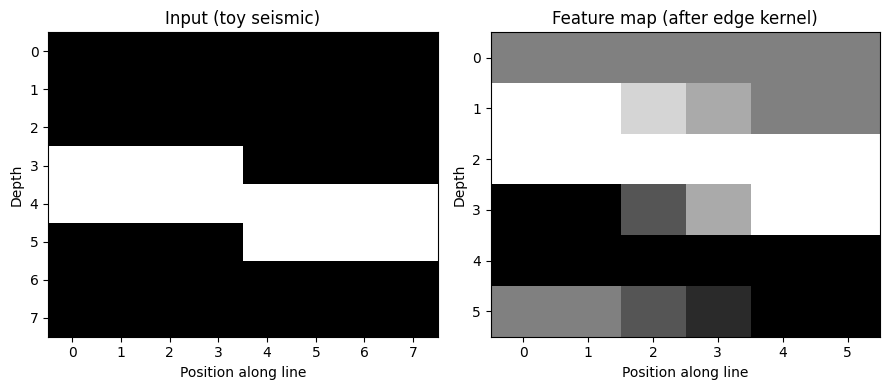

Notice the bright/dark band in the feature map lines up exactly with the layer boundaries --
and the tiny fault step in the toy image produces a visible kink in that band.


In [3]:
# A horizontal-edge detection kernel: strongly positive where a bright layer sits
# above a dark one, strongly negative the other way round
edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

feature_map = manual_convolve2d(toy, edge_kernel)
print("Feature map shape:", feature_map.shape, " (8x8 input, 3x3 kernel, no padding -> 6x6 output)")
print(np.round(feature_map, 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(toy, cmap="gray", aspect="auto")
axes[0].set_title("Input (toy seismic)")
axes[1].imshow(feature_map, cmap="gray", aspect="auto")
axes[1].set_title("Feature map (after edge kernel)")
for ax in axes:
    ax.set_xlabel("Position along line")
    ax.set_ylabel("Depth")
plt.tight_layout()
plt.show()
print("Notice the bright/dark band in the feature map lines up exactly with the layer boundaries --")
print("and the tiny fault step in the toy image produces a visible kink in that band.")

---
## 3. Kernels as Pattern Detectors

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Different kernels detect different patterns. Below are two more classic, hand-designed kernels.
In a real CNN, we never write these numbers by hand -- **the kernel values are learned weights**,
adjusted by backpropagation exactly like every weight in Lesson 16. We use hand-picked kernels here
only so the numbers are interpretable before autograd takes over.
</div>

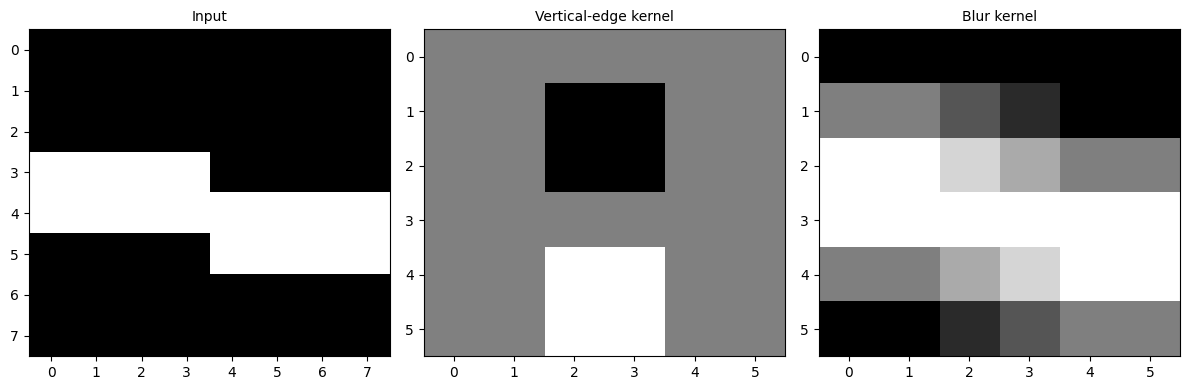

The vertical kernel responds to left-right changes (weak here -- our layers are horizontal).
The blur kernel just smooths everything -- useful for noise reduction, not for finding faults.


In [4]:
vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

blur_kernel = np.ones((3, 3)) / 9.0   # simple averaging kernel -- smooths the image

fmap_vertical = manual_convolve2d(toy, vertical_kernel)
fmap_blur = manual_convolve2d(toy, blur_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Input", "Vertical-edge kernel", "Blur kernel"]
images = [toy, fmap_vertical, fmap_blur]
for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray", aspect="auto")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()
print("The vertical kernel responds to left-right changes (weak here -- our layers are horizontal).")
print("The blur kernel just smooths everything -- useful for noise reduction, not for finding faults.")

---
## 4. Pooling: Keeping What Matters

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

After convolution, **pooling** shrinks the feature map by summarizing small windows -- usually with
**max pooling**: take the largest value in each 2x2 block, discard the rest. This does two things:

1. Reduces the number of values flowing to the next layer (fewer parameters downstream).
2. Keeps the *strongest* signal in each region -- a small shift in exactly where a fault edge falls
   barely changes the pooled output, which makes the network more tolerant of position.
</div>

In [5]:
def manual_max_pool2d(fmap, size=2):
    h, w = fmap.shape
    oh, ow = h // size, w // size
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            block = fmap[i*size:(i+1)*size, j*size:(j+1)*size]
            out[i, j] = block.max()
    return out

pooled = manual_max_pool2d(feature_map, size=2)
print(f"Feature map shape before pooling: {feature_map.shape}")
print(f"Feature map shape after 2x2 max pooling: {pooled.shape}")
print()
print(np.round(pooled, 2))

Feature map shape before pooling: (6, 6)
Feature map shape after 2x2 max pooling: (3, 3)

[[ 2.4  1.6 -0. ]
 [ 2.4  2.4  2.4]
 [-0.  -0.8 -2.4]]


---
## 5. Building Blocks in PyTorch: Conv2d, MaxPool2d, Flatten

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Everything above -- sliding a kernel, summing products, max-pooling -- is exactly what these three
PyTorch layers do, fully vectorized and with **learnable** kernel weights:

| Layer | What it does | Key arguments |
|---|---|---|
| `nn.Conv2d(in_channels, out_channels, kernel_size, padding)` | Slides `out_channels` learned kernels over the input | `padding=1` with `kernel_size=3` keeps the image the same height/width |
| `nn.MaxPool2d(kernel_size)` | Max-pools each window | `kernel_size=2` halves height and width |
| `nn.Flatten()` | Collapses the final `(channels, height, width)` feature map into one long vector, ready for `nn.Linear` | -- |

`in_channels=1` because our seismic patches are single-channel (grayscale amplitude), the same way
an RGB photo would use `in_channels=3`.
</div>

In [6]:
# Confirm shapes: PyTorch expects images as (batch, channels, height, width)
toy_t = torch.tensor(toy, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 8, 8)
print("Input tensor shape:", toy_t.shape)

conv_demo = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
pool_demo = nn.MaxPool2d(kernel_size=2)

with torch.no_grad():
    out_conv = conv_demo(toy_t)
    out_pool = pool_demo(out_conv)

print("After Conv2d(1 -> 4 channels, padding=1):", out_conv.shape, " (padding kept 8x8 spatial size)")
print("After MaxPool2d(2):                       ", out_pool.shape, " (halved to 4x4)")
print()
print("4 output channels means 4 independent learned kernels ran over the same input --")
print("each one free to specialize in detecting a different pattern during training.")

Input tensor shape: torch.Size([1, 1, 8, 8])
After Conv2d(1 -> 4 channels, padding=1): torch.Size([1, 4, 8, 8])  (padding kept 8x8 spatial size)
After MaxPool2d(2):                        torch.Size([1, 4, 4, 4])  (halved to 4x4)

4 output channels means 4 independent learned kernels ran over the same input --
each one free to specialize in detecting a different pattern during training.


---
## 6. A Synthetic Seismic Fault Dataset

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Labelled field seismic (real amplitude volumes with a geologist's fault picks) is large and mostly
proprietary. The standard approach in the fault-detection literature -- including the CNN papers
referenced in this course's reading list -- is to **train first on synthetic seismic** that mimics
the key visual signature of a fault (a lateral offset in otherwise continuous reflectors), then
fine-tune on real data. We do the same thing here, at classroom scale.

Each patch is a 64x64 image with several wavy, dipping reflectors. Half the patches have a **fault**:
a sharp vertical offset of the reflectors partway across the image. The task: **fault present, or not?**
</div>

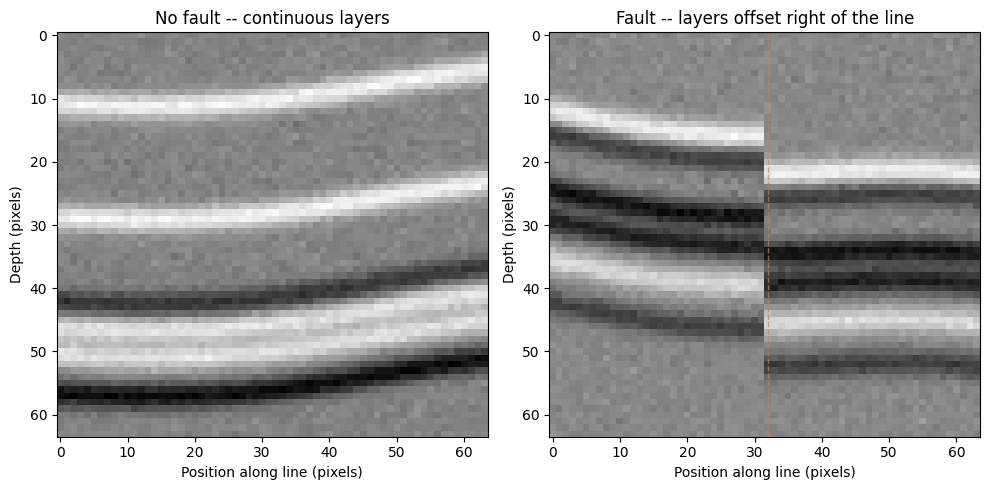

In [7]:
def make_seismic_patch(size=64, n_layers=6, fault=False, fault_shift=6.0, noise=0.05, rng=None):
    """Generate one synthetic seismic patch (wavy layered reflectors, optional fault offset)."""
    rng = rng or np.random.default_rng()
    img = np.zeros((size, size))

    depths = np.sort(rng.uniform(6, size - 6, size=n_layers))
    amps = rng.uniform(0.6, 1.0, size=n_layers) * rng.choice([-1.0, 1.0], size=n_layers)
    dip = rng.uniform(-0.12, 0.12)
    wave_amp = rng.uniform(0.5, 2.5)
    wave_freq = rng.uniform(0.06, 0.15)
    idx = np.arange(size)

    for col in range(size):
        shift = dip * col + wave_amp * np.sin(wave_freq * col)
        col_depths = depths + shift
        if fault and col >= size // 2:
            col_depths = col_depths + fault_shift
        for d, a in zip(col_depths, amps):
            img[:, col] += a * np.exp(-((idx - d) ** 2) / (2 * 1.4 ** 2))

    img += rng.normal(0, noise, size=(size, size))
    return img

rng = np.random.default_rng(42)
example_no_fault = make_seismic_patch(fault=False, rng=rng)
example_fault = make_seismic_patch(fault=True, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(example_no_fault, cmap="gray", aspect="auto")
axes[0].set_title("No fault -- continuous layers")
axes[1].imshow(example_fault, cmap="gray", aspect="auto")
axes[1].axvline(32, color="#e07b39", linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_title("Fault -- layers offset right of the line")
for ax in axes:
    ax.set_xlabel("Position along line (pixels)")
    ax.set_ylabel("Depth (pixels)")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

def make_dataset(n_per_class=200, rng=None):
    rng = rng or np.random.default_rng(0)
    images, labels = [], []
    for _ in range(n_per_class):
        images.append(make_seismic_patch(fault=False, rng=rng))
        labels.append(0)
        images.append(make_seismic_patch(fault=True, rng=rng))
        labels.append(1)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

rng = np.random.default_rng(42)
X, y = make_dataset(n_per_class=200, rng=rng)
print("Dataset shape:", X.shape, " (N patches, 64x64 each)")
print("Labels: 0 = no fault, 1 = fault. Class balance:", np.bincount(y.astype(int)))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# PyTorch images need a channel dimension: (N, 1, H, W)
X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).view(-1, 1)
y_test_t = torch.tensor(y_test).view(-1, 1)

print("\nTraining tensor shape:", X_train_t.shape)
print("Test tensor shape:    ", X_test_t.shape)

Dataset shape: (400, 64, 64)  (N patches, 64x64 each)
Labels: 0 = no fault, 1 = fault. Class balance: [200 200]

Training tensor shape: torch.Size([320, 1, 64, 64])
Test tensor shape:     torch.Size([80, 1, 64, 64])


---
## 7. Your First CNN with nn.Sequential

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Two convolution blocks (`Conv2d -> ReLU -> MaxPool2d`), then flatten and finish with the same kind
of dense layers from Lesson 16. `padding=1` with a 3x3 kernel keeps spatial size unchanged inside
each block, so pooling alone controls the shrinkage: 64 -> 32 -> 16.
</div>

In [9]:
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 1 -> 8 channels, 64x64 -> 64x64
    nn.ReLU(),
    nn.MaxPool2d(2),                             # 64x64 -> 32x32

    nn.Conv2d(8, 16, kernel_size=3, padding=1),  # 8 -> 16 channels, 32x32 -> 32x32
    nn.ReLU(),
    nn.MaxPool2d(2),                             # 32x32 -> 16x16

    nn.Flatten(),                                # 16 x 16 x 16 = 4096 values
    nn.Linear(16 * 16 * 16, 32),
    nn.ReLU(),
    nn.Linear(32, 1)                             # one logit: fault (1) vs no fault (0)
)

print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")
print("Compare this to a flatten-then-dense network on the same 4,096 pixels (Section 1) --")
print("weight *sharing* inside each Conv2d kernel is what keeps this number manageable.")

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=4096, out_features=32, bias=True)
  (8): ReLU()
  (9): Linear(in_features=32, out_features=1, bias=True)
)

Total trainable parameters: 132,385
Compare this to a flatten-then-dense network on the same 4,096 pixels (Section 1) --
weight *sharing* inside each Conv2d kernel is what keeps this number manageable.


---
## 8. Loss and Optimizer for Image Classification

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Lesson 16 used `nn.MSELoss()` for a regression target (porosity, a continuous number). Today's target
is binary (fault / no fault), so we use `nn.BCEWithLogitsLoss()` -- Binary Cross-Entropy. It expects
the model's raw output (a "logit"), and internally applies a sigmoid to squash it into a 0-1
probability before comparing to the true 0/1 label. Using this combined loss instead of a separate
sigmoid + `nn.BCELoss()` is more numerically stable -- the standard PyTorch recommendation.
</div>

In [10]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

with torch.no_grad():
    logits_untrained = model(X_train_t)
    initial_loss = loss_fn(logits_untrained, y_train_t)
print(f"BCE loss before any training: {initial_loss.item():.4f}")
print("(random guessing on a balanced binary problem gives BCE loss near ln(2) = 0.693)")

BCE loss before any training: 0.6951
(random guessing on a balanced binary problem gives BCE loss near ln(2) = 0.693)


---
## 9. The Training Loop

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same four steps as Lesson 16, Section 8: forward pass, compute loss, backward pass, optimizer step.
We additionally track training **accuracy** each epoch by turning logits into 0/1 predictions with
`(logits > 0)`, which is equivalent to checking whether the sigmoid probability exceeds 0.5.
</div>

In [11]:
n_epochs = 40
train_losses, train_accs = [], []

for epoch in range(n_epochs):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds = (logits > 0).float()
        acc = (preds == y_train_t).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs}  |  loss = {loss.item():.4f}  |  train acc = {acc:.3f}")

Epoch   5/40  |  loss = 0.6540  |  train acc = 0.703


Epoch  10/40  |  loss = 0.5780  |  train acc = 0.744


Epoch  15/40  |  loss = 0.4893  |  train acc = 0.778


Epoch  20/40  |  loss = 0.3906  |  train acc = 0.850


Epoch  25/40  |  loss = 0.2986  |  train acc = 0.900


Epoch  30/40  |  loss = 0.2150  |  train acc = 0.928


Epoch  35/40  |  loss = 0.1414  |  train acc = 0.959


Epoch  40/40  |  loss = 0.0853  |  train acc = 0.988


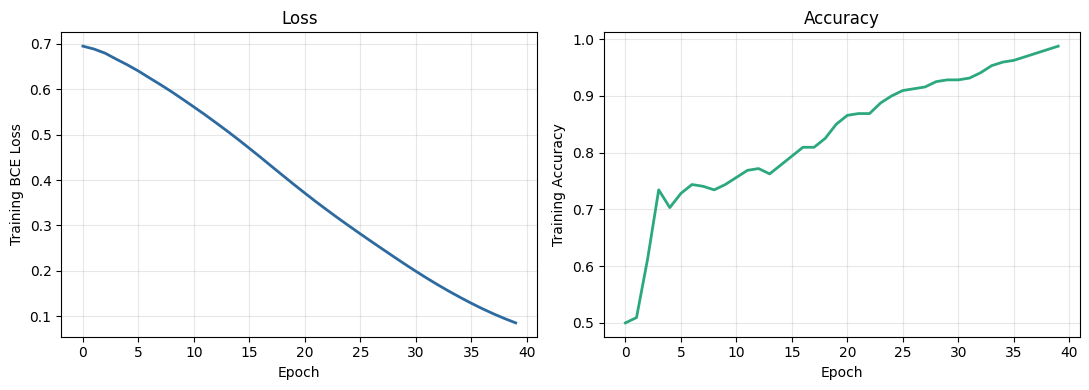

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, color="#2d6a9f", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training BCE Loss"); axes[0].grid(alpha=0.3)
axes[0].set_title("Loss")

axes[1].plot(train_accs, color="#2ca87f", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training Accuracy"); axes[1].grid(alpha=0.3)
axes[1].set_title("Accuracy")
plt.tight_layout()
plt.show()

---
## 10. Evaluate: Accuracy on Held-Out Patches

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

`model.eval()` and `torch.no_grad()` -- same practice as Lesson 16, Section 9 -- before checking
performance on patches the network never trained on.
</div>

In [13]:
from sklearn.metrics import accuracy_score

model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    preds_test = (logits_test > 0).float()

test_acc = accuracy_score(y_test_t.numpy(), preds_test.numpy())
print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.912


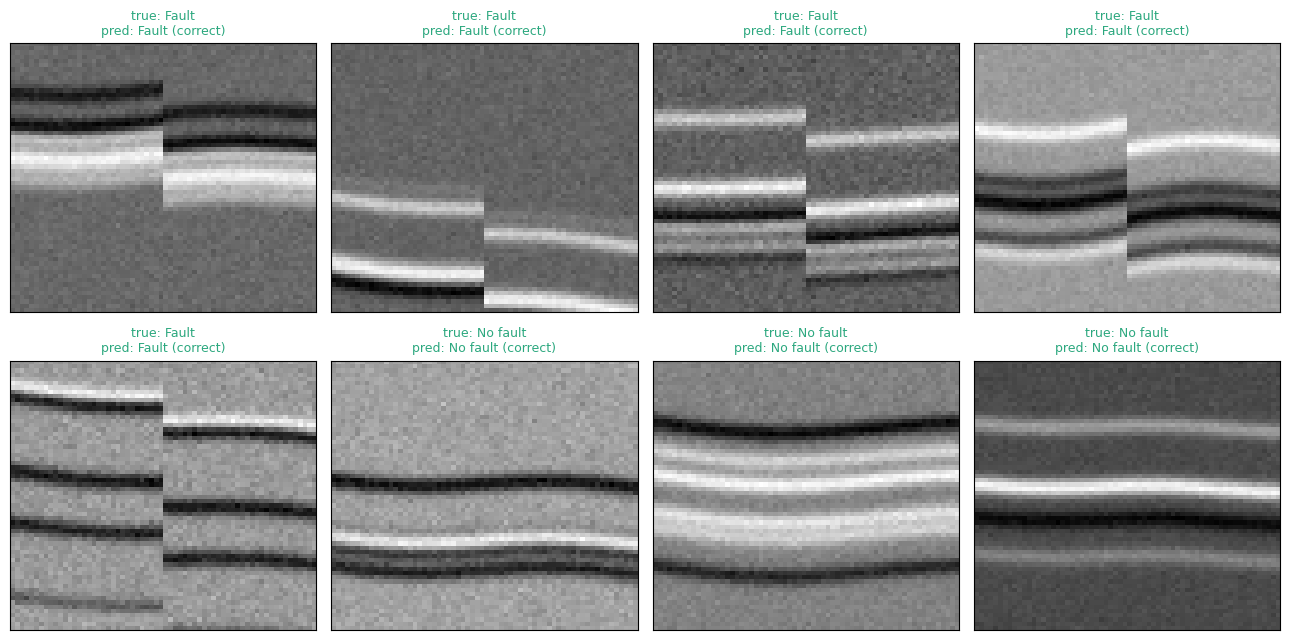

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
rng_show = np.random.default_rng(7)
sample_idx = rng_show.choice(len(X_test), size=8, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_test[idx], cmap="gray", aspect="auto")
    true_label = "Fault" if y_test[idx] == 1 else "No fault"
    pred_label = "Fault" if preds_test[idx].item() == 1 else "No fault"
    correct = "correct" if pred_label == true_label else "WRONG"
    color = "#2ca87f" if correct == "correct" else "#c0392b"
    ax.set_title(f"true: {true_label}\npred: {pred_label} ({correct})", fontsize=9, color=color)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

---
## 11. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Look Inside the Trained Kernels

`model[0]` is the first `Conv2d` layer. Its learned kernels live in `model[0].weight`, shape
`(8, 1, 3, 3)` -- 8 kernels, each `1x3x3`. Plot all 8 as small grayscale images (use
`.detach().numpy()` to pull the tensor out of the graph first).

Do any of them resemble the hand-picked edge or blur kernels from Sections 2-3? Write one sentence
in a new markdown cell describing what you see.
</div>

In [15]:
# Activity -- plot the 8 learned first-layer kernels as a 2x4 grid of small images
# Hint: kernels = model[0].weight.detach().numpy()   # shape (8, 1, 3, 3)
#       kernels[i, 0] is the i-th 3x3 kernel





---
## 12. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| Convolution | Slide a small kernel over an image, multiply and sum, one output pixel per position |
| Kernel / filter | A small learned weight matrix; different kernels detect different patterns |
| Feature map | The output image produced by convolving one kernel across the input |
| Pooling | Downsample a feature map (e.g. max over 2x2 blocks), keeping the strongest signal |
| `nn.Conv2d` / `nn.MaxPool2d` / `nn.Flatten` | PyTorch's vectorized, learnable versions of the manual functions above |
| `nn.BCEWithLogitsLoss` | Binary cross-entropy loss for two-class problems, numerically stable with raw logits |

</div>

### Homework

**Task 1 -- Go Deeper**

Add a third convolution block (`nn.Conv2d(16, 32, kernel_size=3, padding=1)`, `nn.ReLU()`,
`nn.MaxPool2d(2)`) before the `Flatten`, and update the first `nn.Linear` input size accordingly
(spatial size shrinks one more time: 16x16 -> 8x8, so `32 * 8 * 8`). Retrain from scratch and compare
test accuracy to the two-block baseline.

**Task 2 -- Bigger Kernels**

Rebuild the model with `kernel_size=5` (keep `padding=2` so spatial size is still preserved) in both
convolution blocks. Retrain and compare test accuracy and training time to the 3x3 baseline.

**Task 3 (Engineering) -- Make the Task Harder**

In `make_dataset`, increase `noise` to `0.15` and reduce `fault_shift` to `3.0` (a smaller, noisier
offset -- closer to a subtle real fault). Regenerate the dataset, retrain the Section 7 model, and
report the new test accuracy. What does the accuracy drop tell you about detecting subtle faults in
real, noisy seismic data?

In [16]:
# Homework Task 1 -- Go Deeper
# Hint: rebuild model as a 3-conv-block nn.Sequential, fresh optimizer, reuse the Section 9 training loop.





In [17]:
# Homework Task 2 -- Bigger Kernels
# Hint: kernel_size=5, padding=2 in both Conv2d layers; spatial size logic is unchanged (still 64->32->16).





In [18]:
# Homework Task 3 (Engineering) -- Make the Task Harder
# Hint: X, y = make_dataset(n_per_class=200, rng=np.random.default_rng(42))  # then edit noise/fault_shift
#       inside a modified make_seismic_patch call, or pass new defaults.





<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You built a convolution and a max-pool by hand, then trained a real CNN to spot faults in
    synthetic seismic patches. Next, Lesson 18 goes deeper: a three-block CNN, dropout to fight
    overfitting, and evaluation metrics that matter more than accuracy when missing a fault is far
    more costly than a false alarm -- plus a look inside the network at what each layer actually
    "sees."
  </p>
</div>